# Coin Recognition and Counting Project
## Image Processing and Computer Vision Course
---
### 1. Setup and Library Import
In this section, we load the fundamental libraries and define the problem constants, including monetary values and dataset paths.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# Set default figure size for plots
plt.rcParams['figure.figsize'] = (10, 8)

# Dataset folder paths
ref_dir = 'coin_dataset/reference_set/'
target_dir = 'coin_dataset/target_set/'

# Dictionary mapping coin reference names to their real values (in Euros)
COIN_VALUES = {
    '1cent': 0.01, '2cent': 0.02, '5cent': 0.05,
    '10cent': 0.10, '20cent': 0.20, '50cent': 0.50,
    '1euro': 1.00, '2euro': 2.00
}

# Mapping reference images
reference_images = {name: os.path.join(ref_dir, f"{name}.jpg") for name in COIN_VALUES.keys()}

print("Section 1 complete: Libraries loaded and constants initialized.")

Section 1 complete: Libraries loaded and constants initialized.


### 2. Ground Truth Definition
Here we insert the actual coin count data for each test image (`target_set`). This dictionary is fundamental for both quantitative validation of performance and error metrics (MAE).

In [2]:
# ==========================================
# GROUND TRUTH - Actual coin counts per image
# Format: image_number -> actual_coin_count
# ==========================================
GROUND_TRUTH_RAW = {
    1: 3, 2: 1, 3: 6, 4: 1, 5: 1,
    6: 1, 7: 3, 8: 1, 9: 1, 10: 1,
    11: 2, 12: 2, 13: 1, 14: 1, 15: 1,
    16: 2, 17: 3, 18: 3, 19: 1, 20: 3,
    21: 1, 22: 1, 23: 2, 24: 3, 25: 3,
    26: 2, 27: 5, 28: 2, 29: 1, 30: 3,
    31: 2, 32: 3, 33: 1, 34: 1, 35: 1,
    36: 2, 37: 3, 38: 7, 39: 2, 40: 5,
    41: 1, 42: 1, 43: 2, 44: 2, 45: 3,
    46: 3, 47: 3, 48: 1, 49: 3, 50: 2,
    51: 4, 52: 6, 53: 1, 54: 2, 55: 2,
    56: 1, 57: 3, 58: 3, 59: 2, 60: 1,
    61: 1, 62: 2, 63: 3, 64: 1, 65: 1,
    66: 3, 67: 2, 68: 1, 69: 1, 70: 1,
    71: 1, 72: 3, 73: 3, 74: 2, 75: 2,
    76: 4, 77: 3, 78: 3, 79: 5, 80: 2,
    81: 1, 82: 1, 83: 1, 84: 4, 85: 5,
    86: 3, 87: 1, 88: 6, 89: 2, 90: 2,
    91: 1, 92: 3, 93: 1, 94: 3, 95: 3,
    96: 8, 97: 4, 98: 4, 99: 1, 100: 1,
    101: 3, 102: 3, 103: 3, 104: 1, 105: 1,
    106: 3, 107: 1, 108: 1, 109: 2, 110: 2,
    111: 3, 112: 3, 113: 1, 114: 1, 115: 4,
    116: 1, 117: 1, 118: 8, 119: 1, 120: 2,
    121: 4, 122: 3, 123: 1, 124: 3, 125: 2,
    126: 3, 127: 2, 128: 3, 129: 1, 130: 2,
    131: 1, 132: 4, 133: 3, 134: 2, 135: 1,
    136: 2, 137: 3, 138: 3, 139: 2, 140: 2,
    141: 1, 142: 2,
}

HARD_CASES = {11, 24, 27, 32, 36, 40, 43, 55, 79, 85, 103, 132}

print(f"Section 2 complete: Ground Truth loaded for {len(GROUND_TRUTH_RAW)} images.")

Section 2 complete: Ground Truth loaded for 142 images.


### 3. SIFT Descriptor Extraction (Offline Phase)
To optimize computation time, we pre-extract keypoints and SIFT descriptors from the 8 reference model images. These will be stored in memory to be compared later against coin crops.

In [3]:
sift = cv2.SIFT_create()
reference_data = {}

print("Extracting SIFT descriptors from reference models...")
for name, path in reference_images.items():
    if not os.path.exists(path):
        print(f"Warning: File not found for {name} at {path}")
        continue
    img = cv2.imread(path, 0)
    if img is not None:
        kp, des = sift.detectAndCompute(img, None)
        reference_data[name] = {'kp': kp, 'des': des, 'img': img}
        print(f"  -> [{name}]: {len(kp)} keypoints extracted.")

bf = cv2.BFMatcher()
print("Section 3 complete: Reference descriptors ready.")

Extracting SIFT descriptors from reference models...
  -> [1cent]: 126 keypoints extracted.
  -> [2cent]: 60 keypoints extracted.
  -> [5cent]: 102 keypoints extracted.
  -> [10cent]: 75 keypoints extracted.
  -> [20cent]: 115 keypoints extracted.
  -> [50cent]: 118 keypoints extracted.
  -> [1euro]: 201 keypoints extracted.
  -> [2euro]: 133 keypoints extracted.
Section 3 complete: Reference descriptors ready.


### 5. Final Pipeline: Detection (Hough) + Robust Classification (SIFT RANSAC)
This is the definitive approach of the project. We divide the algorithm into two phases:
1. **Localization**: HoughCircles configured with high sensitivity alongside a Bilateral Filter (Lecture 2) to isolate even partially covered coins.
2. **Classification**: Cropping the coin, applying a Circular Mask to remove the background, Contrast Stretching, and RANSAC geometric verification (Lab 2) to avoid false matches between different coins.

In [4]:
# ==========================================
# SECTION 3: THE DETECTION & CLASSIFICATION PIPELINE
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def classify_coin_sift_robust(coin_roi, reference_data, bf_matcher, r_detected, mask=None):
    """ Classifies a coin using SIFT, Lowe's Ratio Test, Masking, AND Geometric Veto. """
    if coin_roi is None or coin_roi.shape[0] < 20 or coin_roi.shape[1] < 20:
        return "Unknown", 0

    roi_norm = cv2.normalize(coin_roi, None, 0, 255, cv2.NORM_MINMAX)
    kp_target, des_target = sift.detectAndCompute(roi_norm, mask)
    
    if des_target is None or len(kp_target) < 3:
        return "Unknown", 0

    best_match_name = "Unknown"
    max_good_matches = 0 

    for ref_name, ref_data in reference_data.items():
        
        # ==========================================
        # 🛡️ IL VETO GEOMETRICO SUL RAGGIO
        # ==========================================
        # Gruppo Grandi: 50cent, 1euro, 2euro
        # Gruppo Piccole: 1cent, 2cent, 5cent, 10cent, 20cent
        
        SOGLIA_RAGGIO = 48 # Modifica questo valore in base al Passo 1!

        # 1. Se Hough dice che la moneta è PICCOLA...
        if r_detected < SOGLIA_RAGGIO:
            # ...vietiamo a SIFT di confrontarla con le monete grandi!
            if ref_name in ['50cent', '1euro', '2euro']:
                continue 
                
        # 2. Se Hough dice che la moneta è GRANDE...
        elif r_detected >= SOGLIA_RAGGIO:
            # ...vietiamo a SIFT di confrontarla con le monete piccole!
            if ref_name in ['1cent', '2cent', '5cent', '10cent', '20cent']:
                continue
        # ==========================================

        # Se passa il veto, esegue il normale SIFT
        matches = bf_matcher.knnMatch(ref_data['des'], des_target, k=2)
        
        good_matches = []
        for pair in matches:
            if len(pair) == 2:
                m, n = pair
                if m.distance < 0.85 * n.distance:
                    good_matches.append(m)
        
        if len(good_matches) > max_good_matches:
            max_good_matches = len(good_matches)
            best_match_name = ref_name

    if max_good_matches < 4:
        return "Unknown", max_good_matches

    return best_match_name, max_good_matches


def process_image(image_path, reference_data, bf_matcher):
    """ Main pipeline: MedianBlur Preprocessing -> Hough Detection -> Masked SIFT """
    img = cv2.imread(image_path)
    if img is None: 
        print(f"❌ ERROR: Image not found -> {image_path}")
        return
    
    max_width = 1200
    if img.shape[1] > max_width:
        scale = max_width / img.shape[1]
        img = cv2.resize(img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))
    
    gray_for_sift = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. PREPROCESSING: Il MedianBlur a 21 distrugge i dettagli interni per aiutare Hough
    blurred_for_hough = cv2.medianBlur(gray_for_sift, 21) 

    # 2. DETECTION: Parametri ottimizzati per ignorare il rumore del tavolo
    circles = cv2.HoughCircles(
        blurred_for_hough, cv2.HOUGH_GRADIENT, dp=1.2, 
        minDist=50, param1=50, param2=30, minRadius=20, maxRadius=150 
    )

    result_img = img.copy()
    total_value = 0.0
    valid_coins = 0
    
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        print(f"🔎 Hough detected {len(circles)} coins. Running SIFT analysis...")
        
        for (x, y, r) in circles:
            r_crop = int(r)
            y1, y2 = max(0, y - r_crop), min(img.shape[0], y + r_crop)
            x1, x2 = max(0, x - r_crop), min(img.shape[1], x + r_crop)
            print(f"📏 Raggio rilevato da Hough: {r_crop} pixel")
            
            # Forniamo a SIFT l'immagine con i dettagli (non sfocata)
            coin_roi = gray_for_sift[y1:y2, x1:x2]
            
            if coin_roi.shape[0] < 20 or coin_roi.shape[1] < 20:
                continue

            # Maschera circolare per eliminare lo sfondo del tavolo
            mask = np.zeros_like(coin_roi)
            cv2.circle(mask, (x - x1, y - y1), r_crop, 255, -1)
            
            # 3. CLASSIFICATION: Passiamo ROI e Maschera
            # 3. CLASSIFICATION: Passiamo ROI, Maschera E IL RAGGIO (r)
            coin_name, matches_count = classify_coin_sift_robust(coin_roi, reference_data, bf_matcher, r_detected=r, mask=mask)
            if coin_name != "Unknown":
                color = (0, 255, 0) # Verde = Riconosciuta
                total_value += COIN_VALUES.get(coin_name, 0)
                valid_coins += 1
                label = f"{coin_name} ({matches_count})"
            else:
                color = (0, 0, 255) # Rosso = Sconosciuta
                label = f"Unknown ({matches_count})"
                
            cv2.circle(result_img, (x, y), r, color, 3)
            cv2.circle(result_img, (x, y), 4, (255, 0, 0), -1) 
            cv2.putText(result_img, label, (x - 20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    else:
        print("⚠️ No circles detected.")

    print(f"✅ Final Result: {valid_coins} coins recognized. Total Value: € {total_value:.2f}")
    
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

print("✅ Section 3 complete: Core Engine updated.")

✅ Section 3 complete: Core Engine updated.


In [14]:
def detect_and_classify_final_pure(image_path, reference_data):
    img = cv2.imread(image_path)
    if img is None: 
        print(f"ERROR: Image not found -> {image_path}")
        return
    
    # Balanced resizing to 1200px to preserve texture analyzed by SIFT
    max_width = 1200
    if img.shape[1] > max_width:
        scale = max_width / img.shape[1]
        img = cv2.resize(img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Academic Preprocessing (Lecture 2): Bilateral filter preserves critical edges
    blurred = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    # High sensitivity configuration to handle overlapping.
    # minDist=30 natively prevents the creation of duplicate circles on the same coin.
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.2, 
        minDist=35, param1=60, param2=27, minRadius=20, maxRadius=100 
    )

    result_img = img.copy()
    total_value = 0.0
    
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        print(f"HoughCircles detected {len(circles)} circular areas. Starting SIFT analysis...")
        
        for (x, y, r) in circles:
            r_crop = int(r)
            y1, y2 = max(0, y - r_crop), min(img.shape[0], y + r_crop)
            x1, x2 = max(0, x - r_crop), min(img.shape[1], x + r_crop)
            coin_roi_square = gray[y1:y2, x1:x2]
            
            # Numpy Circular Mask to zero out corners outside the coin (Lab 1)
            mask = np.zeros_like(coin_roi_square)
            center_crop = (x - x1, y - y1)
            cv2.circle(mask, center_crop, r_crop, 255, -1)
            coin_roi_masked = cv2.bitwise_and(coin_roi_square, coin_roi_square, mask=mask)
            
            # Classification
            coin_name, inliers = classify_coin_sift_robust(coin_roi_masked, reference_data, bf)
            
            if coin_name != "Unknown":
                color = (0, 255, 0) # Green if validated by SIFT RANSAC
                total_value += COIN_VALUES.get(coin_name, 0)
            else:
                color = (0, 0, 255) # Red if the area is uncertain or unclassifiable
                
            # Drawing graphics and labels
            cv2.circle(result_img, (x, y), r, color, 3)
            cv2.circle(result_img, (x, y), 4, (255, 0, 0), -1) 
            label = f"{coin_name} ({inliers})"
            cv2.putText(result_img, label, (x - 20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    else:
        print("No circles detected in this image.")

    print(f"Estimated total value: € {total_value:.2f}")
    
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

print("Pipeline 'detect_and_classify_final_pure' ready.")

Pipeline 'detect_and_classify_final_pure' ready.


### 6. Execution and Testing on Critical Cases
We use this final cell to run our complete pipeline and visually examine the results on coin counting and recognition in complex image cases or with overlapping coins.

🚀 Starting test on: coin_dataset/target_set/image_101.jpg
🔎 Hough detected 2 coins. Running SIFT analysis...
📏 Raggio rilevato da Hough: 81 pixel
📏 Raggio rilevato da Hough: 80 pixel
✅ Final Result: 2 coins recognized. Total Value: € 3.00


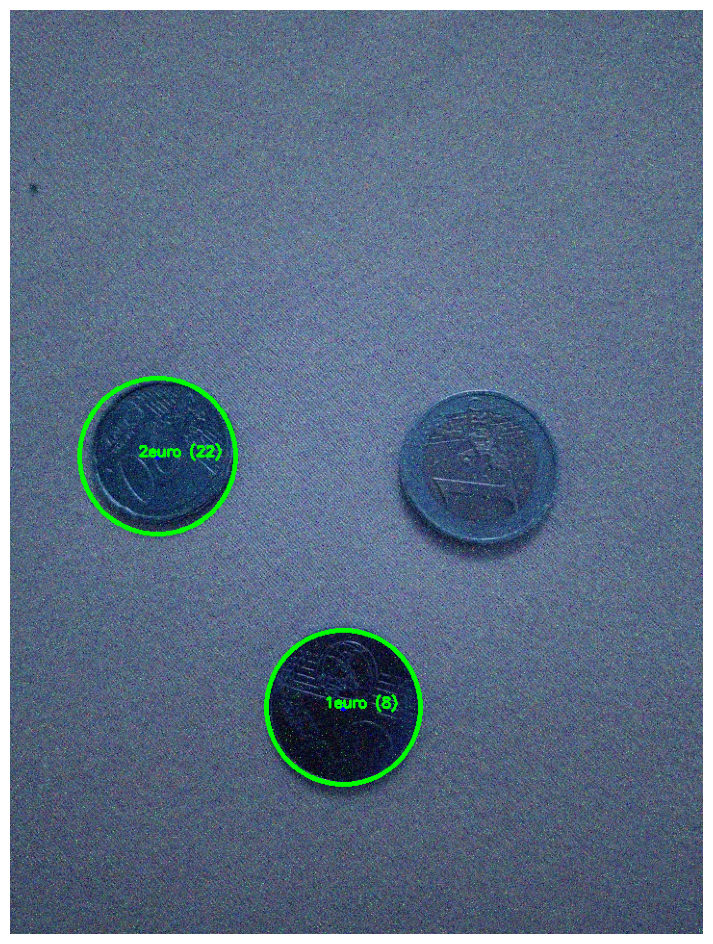

In [15]:
# ==========================================
# SECTION 4: TESTING & EXECUTION
# ==========================================
# Cambia questo nome per testare foto diverse
test_file = 'image_101.jpg' 

target_path = os.path.join(target_dir, test_file)
print(f"🚀 Starting test on: {target_path}")

# Chiamiamo la nuova funzione pulita!
process_image(target_path, reference_data, bf)

🔎 TROVATI 2 CERCHI


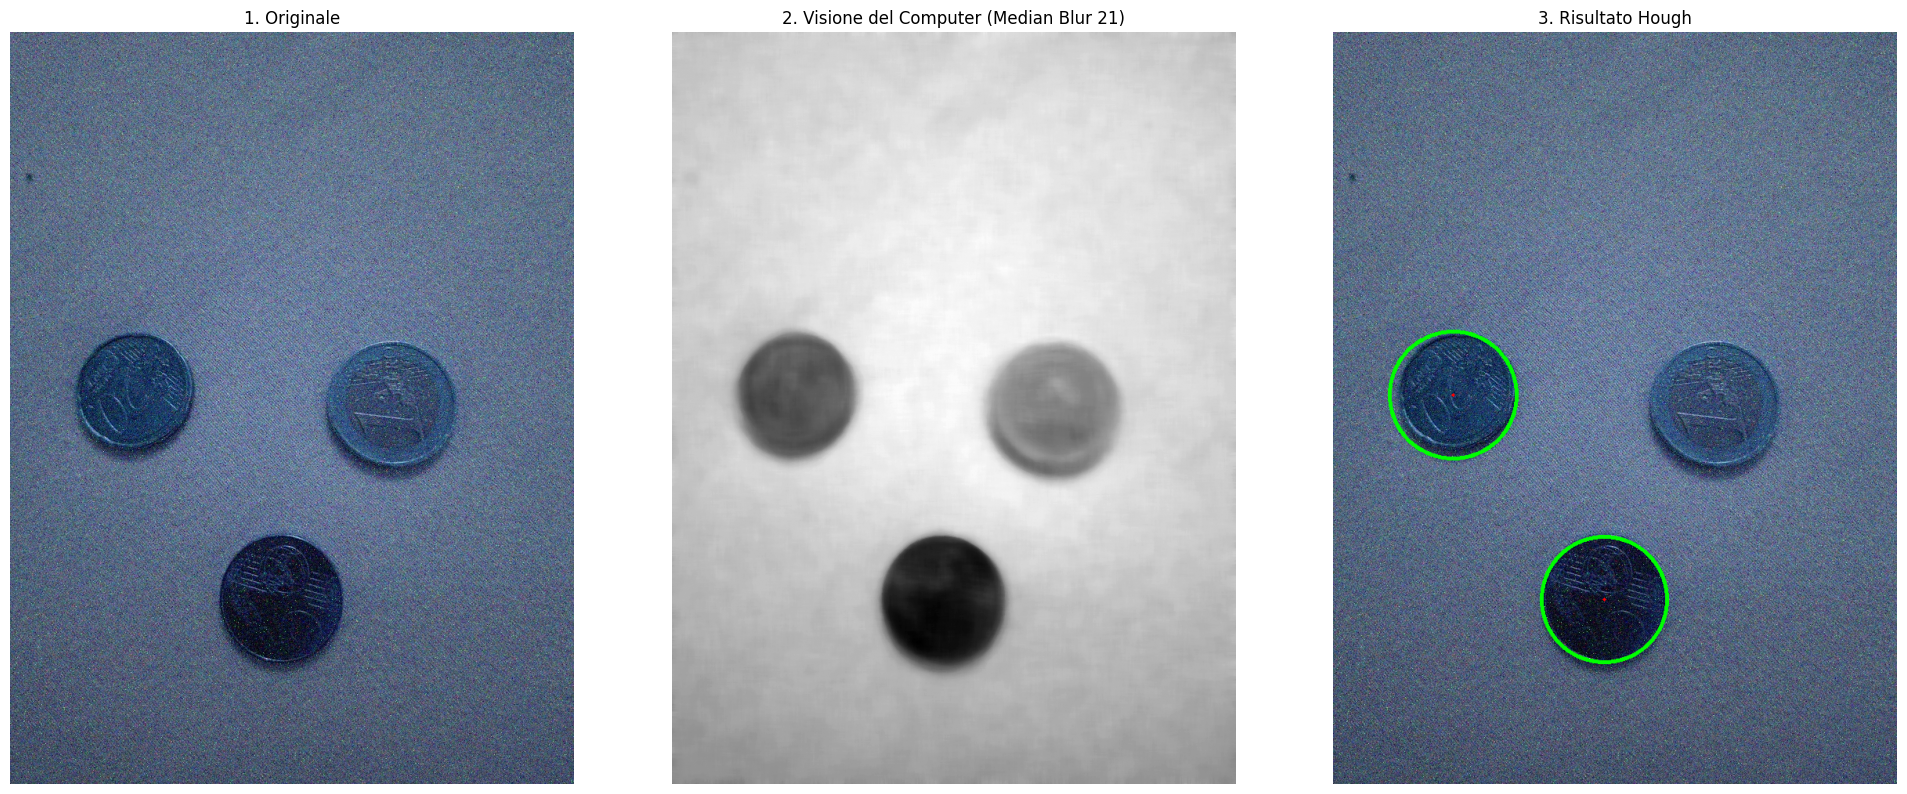

In [10]:
# ==========================================
# 🛠️ DETECTOR LAB: CELLA DI DEBUG VISIVO
# ==========================================
# Usa questa cella per capire PERCHÉ Hough sbaglia e testare i filtri
# SENZA dover aspettare i calcoli di SIFT.

def debug_hough_circles(image_path):
    img = cv2.imread(image_path)
    if img is None: 
        print(f"❌ Impossibile caricare {image_path}")
        return
        
    # 1. Resize standard (stesso della pipeline)
    max_width = 1200
    if img.shape[1] > max_width:
        scale = max_width / img.shape[1]
        img = cv2.resize(img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # ========================================================
    # 🧪 TEST PREPROCESSING: Il tuo intuito originale (Blur 21)
    # Distrugge i dettagli interni, salva i bordi.
    # ========================================================
    blurred = cv2.medianBlur(gray, 21)

    # Parametri Hough
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.2, 
        minDist=50,      # Abbassato leggermente per permettere monete vicine
        param1=50,       # Sensibilità del Canny interno (più basso = vede più bordi)
        param2=30,       # Soglia di perfezione del cerchio
        minRadius=20, maxRadius=150
    )

    # Disegno
    result_img = img.copy()
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        print(f"🔎 TROVATI {len(circles)} CERCHI")
        for (x, y, r) in circles:
            cv2.circle(result_img, (x, y), r, (0, 255, 0), 3) # Cerchio Verde
            cv2.circle(result_img, (x, y), 2, (0, 0, 255), -1) # Centro Rosso
    else:
        print("⚠️ NESSUN CERCHIO TROVATO")

    # Visualizzazione Matplotlib (3 immagini affiancate)
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Originale")
    axes[0].axis('off')
    
    axes[1].imshow(blurred, cmap='gray')
    axes[1].set_title("2. Visione del Computer (Median Blur 21)")
    axes[1].axis('off')
    
    axes[2].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    axes[2].set_title("3. Risultato Hough")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ESECUZIONE TEST
# Inserisci il nome dell'immagine sballata!
debug_hough_circles(os.path.join(target_dir, 'image_101.jpg'))

🔬 Analisi SIFT profonda su: image_101.jpg
🎯 Confronto forzato con il modello: 50cent
📊 Risultato Lowe Ratio Test: 9 match validi trovati.


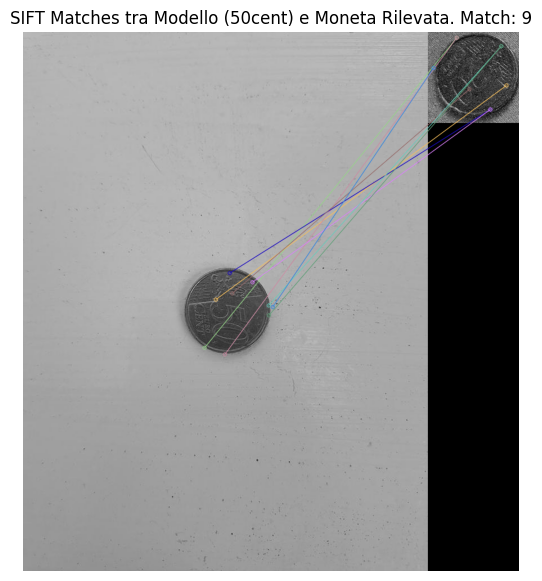

In [13]:
# ==========================================
# 🔬 SIFT LAB: RADIOGRAFIA DEI MATCH
# ==========================================
# Usa questa cella per capire PERCHÈ SIFT sbaglia moneta o fallisce.

def visualize_sift_matches(target_image_path, reference_data, coin_to_test='2euro'):
    print(f"🔬 Analisi SIFT profonda su: {os.path.basename(target_image_path)}")
    print(f"🎯 Confronto forzato con il modello: {coin_to_test}")
    
    # 1. Carica e prepara l'immagine target
    img = cv2.imread(target_image_path)
    max_width = 1200
    if img.shape[1] > max_width:
        scale = max_width / img.shape[1]
        img = cv2.resize(img, (int(img.shape[1] * scale), int(img.shape[0] * scale)))
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 21)
    
    # Trova i cerchi con i nostri parametri infallibili
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.2, 
        minDist=50, param1=50, param2=30, minRadius=20, maxRadius=150 
    )

    if circles is None:
        print("❌ Nessuna moneta trovata da Hough in questa foto.")
        return

    circles = np.round(circles[0, :]).astype("int")
    
    # Prendiamo solo la PRIMA moneta trovata per fare l'analisi
    x, y, r = circles[0]
    r_crop = int(r)
    y1, y2 = max(0, y - r_crop), min(img.shape[0], y + r_crop)
    x1, x2 = max(0, x - r_crop), min(img.shape[1], x + r_crop)
    
    coin_roi = gray[y1:y2, x1:x2]
    mask = np.zeros_like(coin_roi)
    cv2.circle(mask, (x - x1, y - y1), r_crop, 255, -1)
    
    roi_norm = cv2.normalize(coin_roi, None, 0, 255, cv2.NORM_MINMAX)
    
    # Estrazione SIFT target
    sift_debug = cv2.SIFT_create()
    kp_target, des_target = sift_debug.detectAndCompute(roi_norm, mask)
    
    if des_target is None:
        print("❌ SIFT non ha trovato alcun punto sulla moneta target.")
        return
        
    # Prepara i dati del riferimento scelto
    ref_img = reference_data[coin_to_test]['img']
    kp_ref = reference_data[coin_to_test]['kp']
    des_ref = reference_data[coin_to_test]['des']
    
    # Matching
    bf_debug = cv2.BFMatcher()
    matches = bf_debug.knnMatch(des_ref, des_target, k=2)
    
    good_matches = []
    for pair in matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < 0.85 * n.distance:
                good_matches.append(m)
                
    print(f"📊 Risultato Lowe Ratio Test: {len(good_matches)} match validi trovati.")
    
    # Disegna i match!
    # drawMatches collegherà con delle linee i punti della ref_img con i punti della target_img
    match_img = cv2.drawMatches(
        ref_img, kp_ref, 
        roi_norm, kp_target, 
        good_matches, None, 
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    
    plt.figure(figsize=(15, 7))
    plt.imshow(match_img, cmap='gray')
    plt.title(f"SIFT Matches tra Modello ({coin_to_test}) e Moneta Rilevata. Match: {len(good_matches)}")
    plt.axis('off')
    plt.show()

# ESECUZIONE (Metti la foto problematica e dimmi con quale moneta vuoi forzare il confronto)
# Es. se nella foto c'è un 50 centesimi ma non lo riconosce, scrivi '50cent'
visualize_sift_matches(os.path.join(target_dir, 'image_101.jpg'), reference_data, coin_to_test='50cent')